# EDA: Diabetes Indicators (BRFSS 2015)
Business question: which indicators flag diabetes risk and so justify a higher premium?

## Plain-English glossary
| Term | Meaning |
|---|---|
| **Y / "at risk"** | The thing we predict: whether a respondent has **diabetes or prediabetes** (about 16% of people). |
| **Indicator / question** | One survey answer, e.g. high blood pressure, BMI, age. |
| **Rate (%)** | Out of 100 people in a group, how many have diabetes/prediabetes. |
| **Correlation** | A number from -1 to +1 showing how consistently two things move together. It shows association, **not** cause. |


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
df['y'] = (df.Diabetes_012 > 0).astype(int)  # prediabetes or diabetes
X = [c for c in df.columns if c not in ('Diabetes_012','y')]
print(df.shape, 'missing:', df.isna().sum().sum(), 'duplicates:', df.duplicated().sum())
df.describe().T

(253680, 23) missing: 0 duplicates: 23899


,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


## 1. Distribution of Y

> **How to read the chart below**
>
> Each bar is a group of survey respondents: **no diabetes**, **prediabetes**, **diabetes**. The bar height is the **number of people**; the percentage on top is that group's share of everyone surveyed.
> **What to notice:** the 'no diabetes' bar towers over the others, and prediabetes is only about 2%, too few to model on its own. So later we merge prediabetes and diabetes into one 'at risk' group (about 16% of people). This lopsidedness is called *class imbalance*.

                   n   share
Diabetes_012                
No diabetes   213703  0.8424
Diabetes       35346  0.1393
Prediabetes     4631  0.0183
Binary prevalence: 0.1576


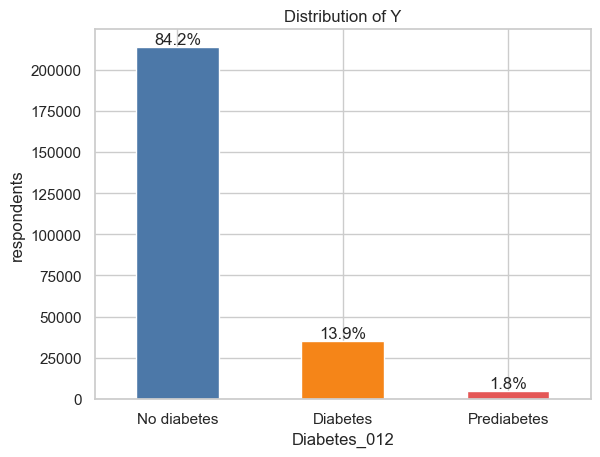

In [2]:
vc = df.Diabetes_012.map({0:'No diabetes',1:'Prediabetes',2:'Diabetes'}).value_counts()
print(pd.DataFrame({'n':vc,'share':(vc/len(df)).round(4)}))
print('Binary prevalence:', df.y.mean().round(4))
ax = vc.plot.bar(color=['#4c78a8','#f58518','#e45756'], rot=0); ax.set_title('Distribution of Y'); ax.set_ylabel('respondents')
for p in ax.patches: ax.annotate(f'{p.get_height()/len(df):.1%}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.show()

**Conclusion:** Only 15.8% are positive, so the data is imbalanced and accuracy is misleading. Use the binary target and judge models on recall/AUC.

## 2. Y vs binary indicators

> **How to read the chart below**
>
> Each row is a yes/no survey question (e.g. high blood pressure). The bar length is a **ratio**: (% with diabetes among people who answered **yes**) divided by (% with diabetes among people who answered **no**).
> - **1** (black line) = no difference. **2** = twice as likely. **Below 1** = *less* likely (protective, e.g. physical activity).
> - Example: high blood pressure about 3.8 means people with high BP are about 3.8 times as likely to have diabetes.
>
> **Watch out:** *CholCheck* is top only because it means "had a cholesterol check". People never checked rarely have a diagnosis. It is a quirk, not a risk factor. Rows overlap (the same person can appear in several), so don't add them up.

             feature  without  with  ratio
   HvyAlcoholConsump    0.163 0.073  0.449
        PhysActivity    0.236 0.132  0.562
             Veggies    0.202 0.147  0.727
              Fruits    0.178 0.146  0.821
                 Sex    0.148 0.170  1.147
       AnyHealthcare    0.135 0.159  1.176
         NoDocbcCost    0.153 0.203  1.325
              Smoker    0.137 0.183  1.336
              Stroke    0.150 0.343  2.293
HeartDiseaseorAttack    0.137 0.358  2.613
            HighChol    0.092 0.247  2.688
            DiffWalk    0.121 0.338  2.786
              HighBP    0.072 0.271  3.756
           CholCheck    0.032 0.162  5.077


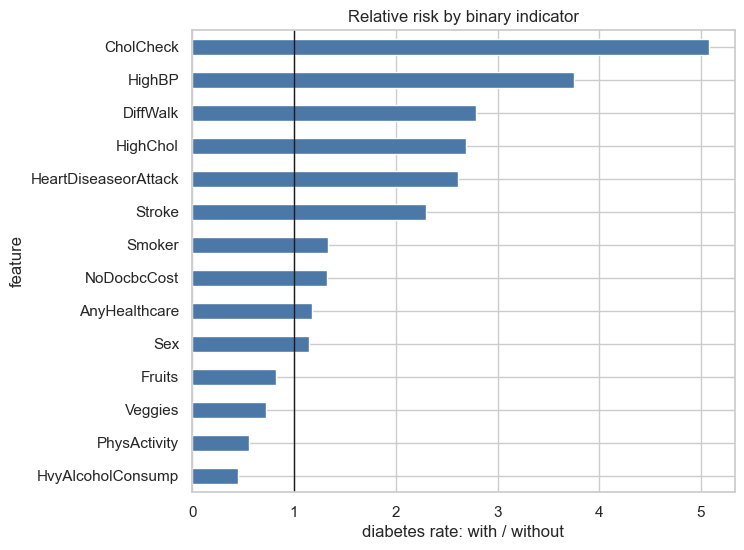

In [3]:
binary = [c for c in X if df[c].nunique()==2]
rows = [(c, df.groupby(c).y.mean()[0], df.groupby(c).y.mean()[1]) for c in binary]
t = pd.DataFrame(rows, columns=['feature','without','with']).assign(ratio=lambda d:d['with']/d['without']).sort_values('ratio')
print(t.round(3).to_string(index=False))
ax = t.set_index('feature')['ratio'].plot.barh(figsize=(7,6), color='#4c78a8')
ax.axvline(1, color='k', lw=1); ax.set_xlabel('diabetes rate: with / without'); ax.set_title('Relative risk by binary indicator')
plt.show()

**Conclusion:** HighBP (3.8x), DiffWalk, HighChol and heart disease carry the biggest risk jumps; PhysActivity is protective. Medical conditions are the strongest, most defensible pricing signals.

## 3. Y vs BMI, age, general health, income, education

> **How to read the chart below**
>
> Five small line charts, one per factor. On each: the **horizontal axis** lists the categories from lowest to highest (BMI band, age group, self-rated health, income, education). The **vertical axis** is the **% with diabetes/prediabetes** in that category. The **grey dashed line** is the overall average (15.8%), so points above it are riskier than average.
> **What to notice:** risk rises with BMI, age and worse health, and falls with income and education.

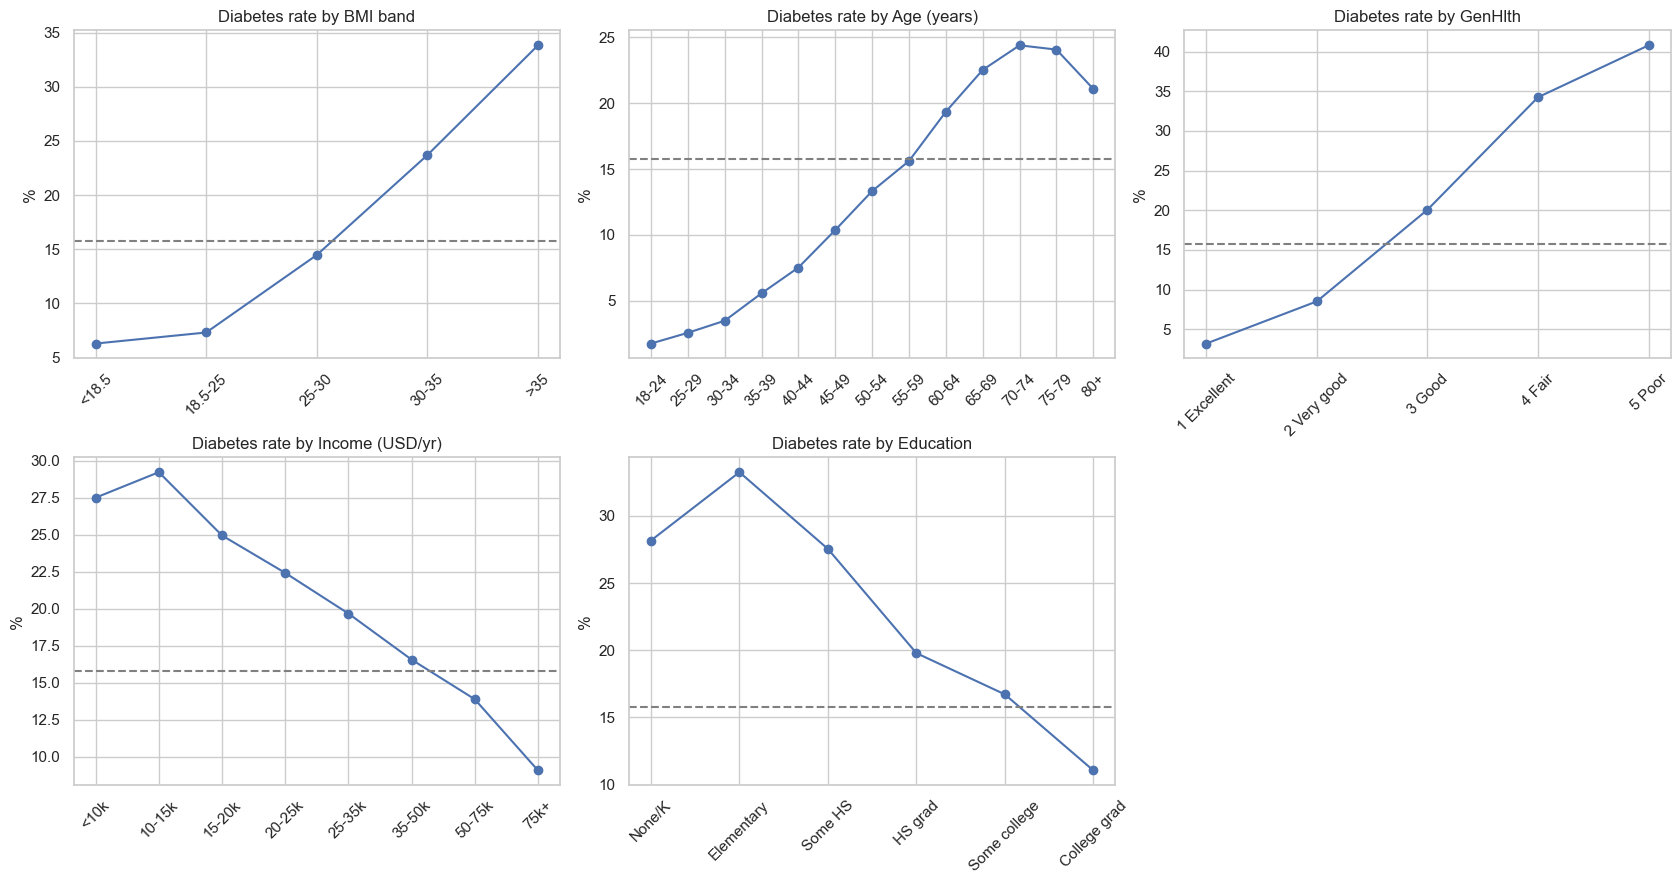

In [4]:
lab = {
 'Age': {1:'18-24',2:'25-29',3:'30-34',4:'35-39',5:'40-44',6:'45-49',7:'50-54',8:'55-59',9:'60-64',10:'65-69',11:'70-74',12:'75-79',13:'80+'},
 'GenHlth': {1:'1 Excellent',2:'2 Very good',3:'3 Good',4:'4 Fair',5:'5 Poor'},
 'Income': {1:'<10k',2:'10-15k',3:'15-20k',4:'20-25k',5:'25-35k',6:'35-50k',7:'50-75k',8:'75k+'},
 'Education': {1:'None/K',2:'Elementary',3:'Some HS',4:'HS grad',5:'Some college',6:'College grad'}}
df['BMI band'] = pd.cut(df.BMI, [0,18.5,25,30,35,100], labels=['<18.5','18.5-25','25-30','30-35','>35'])
fig, axs = plt.subplots(2,3, figsize=(17,9))
for ax, c in zip(axs.flat, ['BMI band','Age','GenHlth','Income','Education']):
    r = df.groupby(c, observed=True).y.mean()
    x = [lab[c][int(i)] for i in r.index] if c in lab else r.index.astype(str)
    ax.plot(x, r.values*100, marker='o'); ax.set_title(f'Diabetes rate by {c}' + (' (years)' if c=='Age' else ' (USD/yr)' if c=='Income' else ''))
    ax.set_ylabel('%'); ax.tick_params(axis='x', rotation=45); ax.axhline(df.y.mean()*100, ls='--', c='grey')
axs.flat[-1].axis('off'); plt.tight_layout(); plt.show()

> **How to read the chart below**
>
> Two smoothed histograms of BMI: one for people **without** diabetes (0) and one **with** it (1). The height shows how common each BMI is *inside its own group* (each group is scaled to the same area so shapes can be compared even though the groups are different sizes).
> **What to notice:** if the 'with diabetes' hump sits further right, people with diabetes tend to have higher BMI.

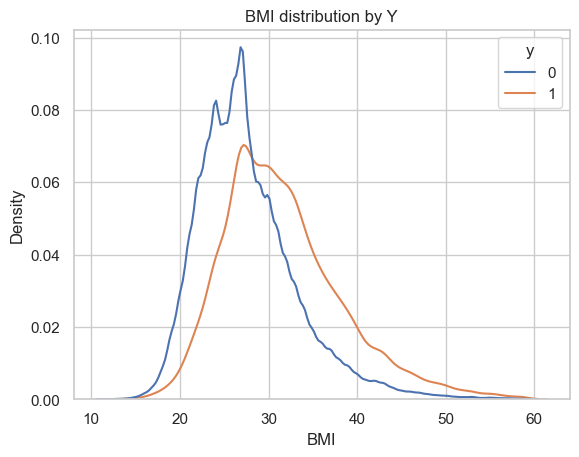

BMI max: 98.0 | BMI > 60: 805


In [5]:
sns.kdeplot(data=df[df.BMI<60], x='BMI', hue='y', common_norm=False); plt.title('BMI distribution by Y'); plt.show()
print('BMI max:', df.BMI.max(), '| BMI > 60:', (df.BMI>60).sum())

**Conclusion:** Risk is low and flat below BMI 25, then climbs about 7-10 points per band (7% to 34%). It climbs with age and with worse general health, and falls with income and education. Treat BMI non-linearly.

## 4. Correlation

> **How to read the chart below**
>
> **Left, bar chart:** how strongly each question moves together with having diabetes. *Correlation* runs from -1 to +1. **Red (positive)** = higher values go with more diabetes. **Blue (negative)** = higher values go with less. Near zero = little link. It shows association, not cause, and misses curved patterns (like BMI).
> **Right, heatmap:** the same measure between **every pair of questions**. Red = move together, blue = move oppositely. It mainly reveals overlapping questions (e.g. blood pressure and cholesterol).

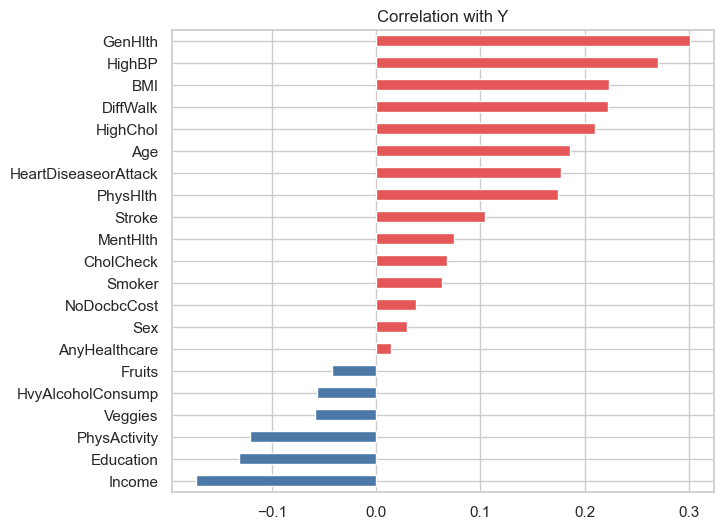

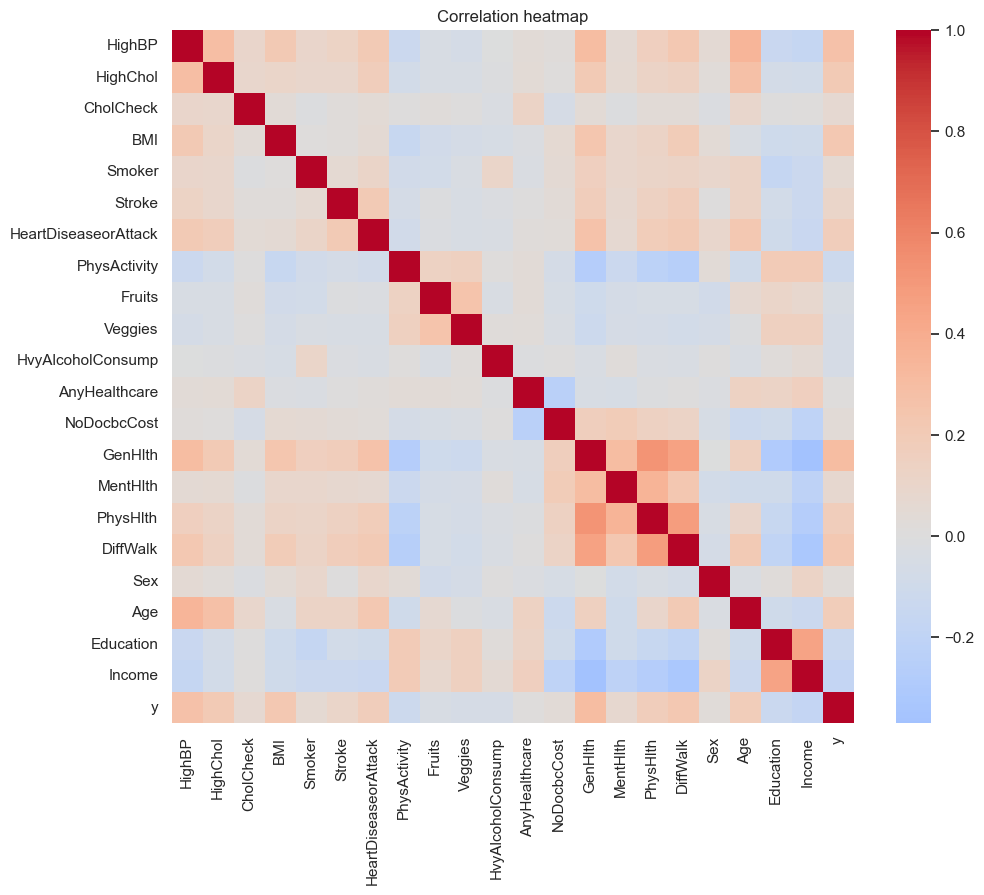

In [6]:
corr = df[X+['y']].corr()['y'].drop('y').sort_values()
corr.plot.barh(figsize=(7,6), color=np.where(corr>0,'#e45756','#4c78a8')); plt.title('Correlation with Y'); plt.show()
plt.figure(figsize=(11,9)); sns.heatmap(df[X+['y']].corr(), cmap='coolwarm', center=0, annot=False); plt.title('Correlation heatmap'); plt.show()

**Conclusion:** GenHlth (0.30), HighBP, BMI, DiffWalk and HighChol correlate most with Y; no single feature is dominant (the top correlation is only 0.30), so signal is spread across many indicators.

## 5. Alcohol paradox: is the protective effect real?
Heavy drinkers show a *lower* diabetes rate. Check whether it survives controlling for age and general health.

> **How to read the chart below**
>
> Test of a puzzle: heavy drinkers have *lower* diabetes rates. Maybe they are just younger or healthier? Both charts compare **non-heavy drinkers (blue)** with **heavy drinkers (orange)**, split by **age group (left)** and **self-rated health, 1 = excellent to 5 = poor (right)**. Bar height = % with diabetes.
> **What to notice:** if age or health explained the puzzle, the blue and orange bars would be about equal within each group. They aren't: the orange bar is lower almost everywhere. The puzzle remains unexplained, so we shouldn't give drinkers a discount.

HvyAlcoholConsump  not heavy  heavy
AgeGrp                             
18-39                    3.8    3.1
40-59                   12.8    6.5
60-69                   21.6    8.9
70+                     23.8   11.0
HvyAlcoholConsump  not heavy  heavy
GenHlth                            
1.0                      3.3    1.9
2.0                      8.8    4.5
3.0                     20.7    9.7
4.0                     34.9   19.3
5.0                     41.4   22.3
Share in poor/fair health (GenHlth>=4): heavy 12.0% vs not heavy 17.5%


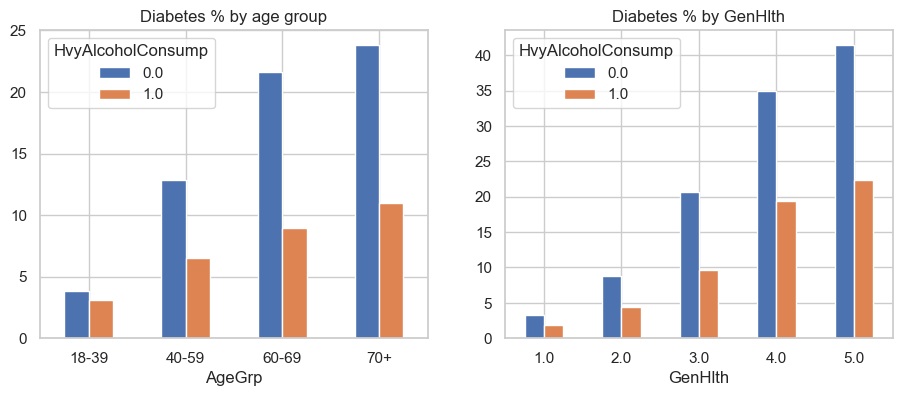

In [7]:
df['AgeGrp']=pd.cut(df.Age,[0,4,8,10,13],labels=['18-39','40-59','60-69','70+'])
t=df.pivot_table(index='AgeGrp',columns='HvyAlcoholConsump',values='y',aggfunc='mean',observed=True)*100
print(t.round(1).rename(columns={0:'not heavy',1:'heavy'}))
t2=df.pivot_table(index='GenHlth',columns='HvyAlcoholConsump',values='y',aggfunc='mean')*100
print(t2.round(1).rename(columns={0:'not heavy',1:'heavy'}))
print('Share in poor/fair health (GenHlth>=4): heavy %.1f%% vs not heavy %.1f%%' % tuple(df.groupby('HvyAlcoholConsump').GenHlth.apply(lambda s:(s>=4).mean()*100).values[::-1]))
fig,axs=plt.subplots(1,2,figsize=(11,4))
t.plot.bar(ax=axs[0],rot=0,title='Diabetes % by age group'); t2.plot.bar(ax=axs[1],rot=0,title='Diabetes % by GenHlth')
plt.show()

**Conclusion:** Heavy drinkers have lower diabetes rates in every age and health group, so age/health don't explain it. Cause unresolved; don't reward drinking in pricing.

## 6. Stacking risk: diabetes rate by number of flags
Flags: HighBP, HighChol, BMI>=30, HeartDiseaseorAttack, DiffWalk, no PhysActivity. Shows where a premium tier could start.

> **How to read the chart below**
>
> We give each person up to **6 'risk flags'**: high blood pressure, high cholesterol, BMI of 30+, heart disease/attack, difficulty walking, not physically active.
> **Left:** the % with diabetes among people with 0, 1, 2 ... 6 flags. **Right:** how many people have each number of flags.
> **What to notice:** risk climbs steeply as flags stack. Most people have 0-2 flags, so the high-flag groups are small but very high risk.

        mean   size
nflags             
0.0      2.7  60336
1.0      7.3  66720
2.0     16.1  57287
3.0     27.5  38428
4.0     39.4  20410
5.0     51.6   8613
6.0     62.4   1886


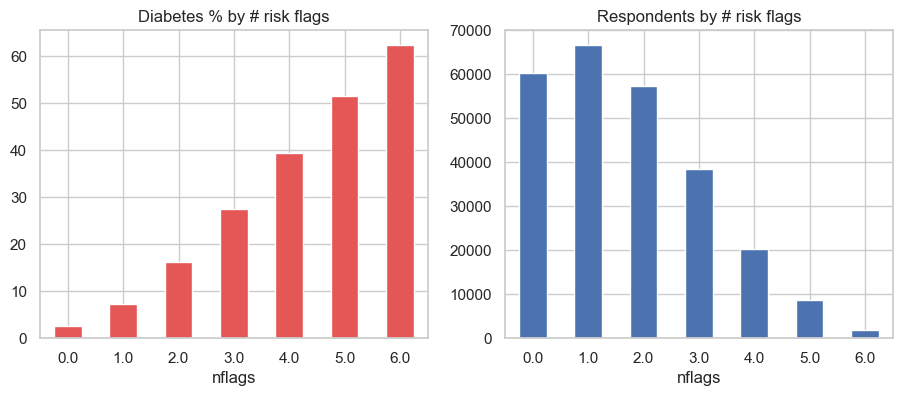

flags>=1: flags 76% of people, catches 96% of diabetics, precision 20%
flags>=2: flags 50% of people, catches 84% of diabetics, precision 26%
flags>=3: flags 27% of people, catches 61% of diabetics, precision 35%
flags>=4: flags 12% of people, catches 34% of diabetics, precision 44%
flags>=5: flags 4% of people, catches 14% of diabetics, precision 54%


In [8]:
df['nflags']=df.HighBP+df.HighChol+(df.BMI>=30)+df.HeartDiseaseorAttack+df.DiffWalk+(1-df.PhysActivity)
f=df.groupby('nflags').y.agg(['mean','size']); f['mean']*=100
print(f.round(1))
fig,ax=plt.subplots(1,2,figsize=(11,4))
f['mean'].plot.bar(ax=ax[0],rot=0,color='#e45756',title='Diabetes % by # risk flags'); f['size'].plot.bar(ax=ax[1],rot=0,title='Respondents by # risk flags')
plt.show()
for k in range(1,6):
    p=df.nflags>=k; print(f'flags>={k}: flags {p.mean():.0%} of people, catches {df.y[p].sum()/df.y.sum():.0%} of diabetics, precision {df.y[p].mean():.0%}')

**Conclusion:** Risk stacks sharply, from 2.7% (0 flags) to 62% (6 flags). 3+ flags (27% of people) catches 61% of diabetics, a sensible starting point for a premium tier.

## 7. Do income and education still matter after medical factors?

> **How to read the chart below**
>
> A heatmap. Each cell is a group defined by **BMI band (rows)** and **income band (columns)**, coloured by the **% with diabetes** (darker red = higher; the number is printed).
> - **Read down a column:** heavier people have more diabetes.
> - **Read across a row:** at the *same* BMI, lower-income groups still have more diabetes.
>
> If income only mattered because poorer people are heavier, each row would be one colour. It isn't, so income carries extra information.

IncGrp  low (1-3)  mid (4-6)  high (7-8)
BMIb                                    
<25          13.9        9.5         4.5
25-30        25.6       17.6         9.9
30+          39.7       30.4        20.8


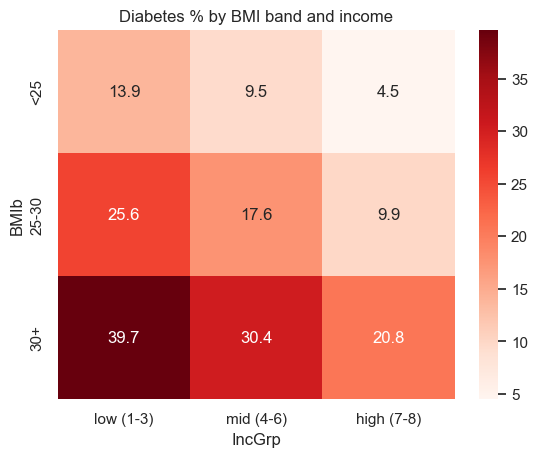

IncGrp  low (1-3)  mid (4-6)  high (7-8)
HighBP                                  
0.0          13.4        9.1         5.1
1.0          37.4       29.2        20.7


In [9]:
df['BMIb']=pd.cut(df.BMI,[0,25,30,100],labels=['<25','25-30','30+'])
d2=df.assign(IncGrp=pd.cut(df.Income,[0,3,6,8],labels=['low (1-3)','mid (4-6)','high (7-8)']))
t=d2.pivot_table(index='BMIb',columns='IncGrp',values='y',aggfunc='mean',observed=True)*100
print(t.round(1)); sns.heatmap(t,annot=True,fmt='.1f',cmap='Reds'); plt.title('Diabetes % by BMI band and income'); plt.show()
t=d2.pivot_table(index='HighBP',columns='IncGrp',values='y',aggfunc='mean',observed=True)*100; print(t.round(1))

**Conclusion:** The income gap persists within every BMI and blood-pressure group (BMI 30+: 40% vs 21%), so it is not only a medical proxy. Strong predictor but a fairness/regulatory risk for pricing.

## 8. Model-based ranking of indicators

> **How to read the chart below**
>
> **Permutation importance:** we scramble one question's answers at random and see how much the model's accuracy (AUC) falls. A **long bar = big drop = the model leans heavily on that question**. This shows what the model *uses*, not what *causes* diabetes.

GB AUC: 0.828
LR AUC: 0.821


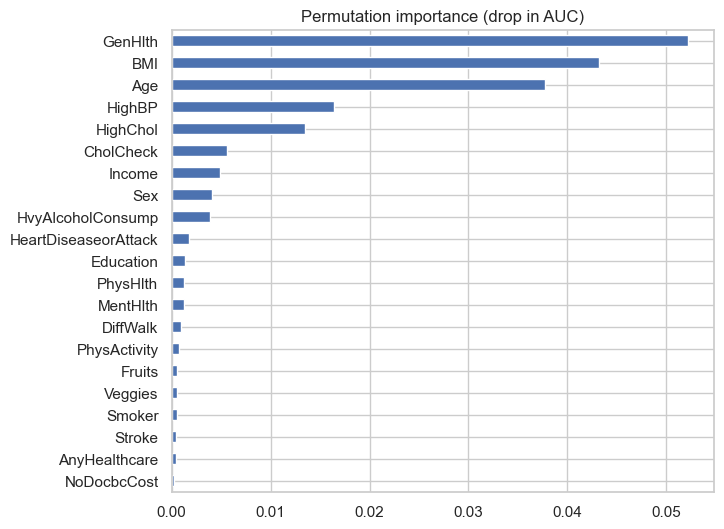

Top-6 ['CholCheck', 'HighChol', 'HighBP', 'Age', 'BMI', 'GenHlth'] AUC: 0.822


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
Xtr,Xte,ytr,yte=train_test_split(df[X],df.y,test_size=0.25,stratify=df.y,random_state=0)
gb=HistGradientBoostingClassifier(random_state=0).fit(Xtr,ytr)
print('GB AUC:',round(roc_auc_score(yte,gb.predict_proba(Xte)[:,1]),3))
lr=LogisticRegression(max_iter=2000,class_weight='balanced').fit((Xtr-Xtr.mean())/Xtr.std(),ytr)
print('LR AUC:',round(roc_auc_score(yte,lr.predict_proba((Xte-Xtr.mean())/Xtr.std())[:,1]),3))
ix=Xtr.sample(40000,random_state=0).index  # rank on TRAIN data so the test set stays untouched for the short-form check
pi=permutation_importance(gb,Xtr.loc[ix],ytr.loc[ix],scoring='roc_auc',n_repeats=5,random_state=0).importances_mean
imp=pd.Series(pi,X).sort_values()
imp.plot.barh(figsize=(7,6),title='Permutation importance (drop in AUC)'); plt.show()
# short form: top 6 features
top=list(imp.index[-6:]); g6=HistGradientBoostingClassifier(random_state=0).fit(Xtr[top],ytr)
print('Top-6',top,'AUC:',round(roc_auc_score(yte,g6.predict_proba(Xte[top])[:,1]),3))

**Conclusion:** AUC is about 0.82-0.83 and a 6-feature short form loses almost nothing, so a short questionnaire is viable. CholCheck is likely an artefact and should be swapped out.

## 9. Findings
- ~15.8% positive; heavily imbalanced.
- Clinical conditions (HighBP, HighChol, heart disease) and BMI > 30 show the largest jumps; BMI effect is non-linear.
- GenHlth is the top single predictor but partly a consequence of disease.
- Income/education are strong but proxy/fairness-sensitive.
- HvyAlcoholConsump is negatively associated and the gap persists within every age group and health level, so age/health do NOT explain it. Likely unmeasured confounding or 'sick quitter' effect; do not reward drinking in pricing.
- 9.4% duplicate rows; kept (likely distinct people with identical answers).
- Association only, from one cross-section; no premium/claims data.
- Risk flags stack: diabetes rate rises from 2.7% (0 flags) to 62% (6 flags). 3+ flags = 27% of people, catches 61% of diabetics, 35% precision.
- Income gap persists inside every BMI band and BP group (e.g. BMI 30+: 40% low vs 21% high income), so it is not just a medical proxy.
- Models: GB AUC 0.83, LR 0.82; top-6 features (CholCheck, HighChol, HighBP, Age, BMI, GenHlth) lose almost nothing (0.822). CholCheck is likely an artefact (people never checked rarely have a diagnosis), not a risk factor.